In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Start with first 10
# 3a-b. Create an ID for each machine (in this case, using a list)
list10 = []
for x in range(1, 11):
    df_temp = pd.read_csv(f"2013-8/{x}.csv", sep=";").rename(columns=str.strip)
    df_temp["machine_id"] = x
    list10.append(df_temp)
# 3c(i). Combine into a single dataframe
df10 = pd.concat(list10)
print(df10.shape)
print(df10.isna().sum())
# 3c(ii). Sort by machine_id then by timestamp
df10 = df10.sort_values(["machine_id", "Timestamp [ms]"])

(146393, 12)
Timestamp [ms]                           0
CPU cores                                0
CPU capacity provisioned [MHZ]           0
CPU usage [MHZ]                          0
CPU usage [%]                            0
Memory capacity provisioned [KB]         0
Memory usage [KB]                        0
Disk read throughput [KB/s]              0
Disk write throughput [KB/s]             0
Network received throughput [KB/s]       0
Network transmitted throughput [KB/s]    0
machine_id                               0
dtype: int64


In [20]:
# For first 10 (extend to 100 and 1000)
# 3d. Convert ms to readable time
df10["datetime"] = pd.to_datetime(df10["Timestamp [ms]"], unit="ms")

In [21]:
df10.head()

,Timestamp [ms],CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s],machine_id,datetime
0,1376314846,4,11703.99824,10912.027692,93.233333,67108864.0,6.129274e+06,0.133333,15981.600000,0.000000,2.133333,1,1970-01-16 22:18:34.846
1,1376315146,4,11703.99824,10890.570362,93.050000,67108864.0,6.755624e+06,1.333333,19137.333333,0.000000,2.600000,1,1970-01-16 22:18:35.146
2,1376315446,4,11703.99824,10434.114431,89.150000,67108864.0,8.947846e+06,2.533333,19974.933333,535.666667,23.933333,1,1970-01-16 22:18:35.446
3,1376315746,4,11703.99824,10539.450415,90.050000,67108864.0,1.879048e+07,5.466667,8791.800000,349.666667,5.466667,1,1970-01-16 22:18:35.746
4,1376316046,4,11703.99824,10951.041020,93.566667,67108864.0,9.305761e+06,5.400000,15679.533333,0.000000,2.066667,1,1970-01-16 22:18:36.046


In [22]:
# 3e(i). Check sampling interval between consecutive, note anomalies
# Filter for above threshold
df10["time_diff_s"] = df10["Timestamp [ms]"].diff() / 1000
df10["time_diff_s"] # Get what this looks like

0          NaN
1        0.300
2        0.300
3        0.300
4        0.300
         ...  
16135    0.000
16136    0.106
16137    0.194
16138    0.000
16139    0.106
Name: time_diff_s, Length: 146393, dtype: float64

In [23]:
# 3e(ii). Look for unusually large gaps
# print(df10["time_diff_s"].describe()) -- do not actually use this

print("UNUSUALLY LARGE GAPS (1.5X MEDIAN)")
print("="*50)


for i in range(1, 10+1):
    machine_x = df10[df10["machine_id"] == i].sort_values("Timestamp [ms]").copy()
    med = machine_x["time_diff_s"].median()
    threshold = med * 1.5

    large_gaps = machine_x[machine_x["time_diff_s"] > threshold]

    print(f"Machine {i}: Found {len(large_gaps)} gaps (Median = {med:.3f}s, Threshold > {threshold:.3f}s)")

UNUSUALLY LARGE GAPS (1.5X MEDIAN)
Machine 1: Found 5 gaps (Median = 0.300s, Threshold > 0.450s)
Machine 2: Found 3 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 3: Found 4 gaps (Median = 0.300s, Threshold > 0.450s)
Machine 4: Found 6 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 5: Found 5 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 6: Found 4 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 7: Found 4 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 8: Found 3 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 9: Found 4 gaps (Median = 0.209s, Threshold > 0.314s)
Machine 10: Found 5 gaps (Median = 0.209s, Threshold > 0.314s)


In [24]:
# 4. calculation of mean, median, min, max, stddev across the ENTIRE set for each metric
metrics = [c for c in df10.columns if c not in ["machine_id", "Timestamp [ms]", "datetime", "time_diff_s"]]
df10[metrics].agg(["mean", "median", "min", "max", "std"])

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
mean,0.472673,1383.040606,63.836810,0.641422,4.940899e+06,6.613911e+04,1.404508,38.216828,2.199703,0.563174
median,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,4.000000,11704.000484,11454.312944,97.866667,6.710886e+07,3.632826e+07,8544.733333,56630.600000,7214.800000,1022.666667
std,1.196398,3500.660632,693.633656,5.957294,1.591654e+07,5.683520e+05,51.103892,701.542713,54.793918,9.837101


In [25]:
# 5. calculate the same mean, median, min, max, stddev across the ENTIRE set for each metric But for EACH MACHINE
df10.groupby("machine_id")[metrics].mean()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
machine_id,,,,,,,,,,
1,4.000000,11703.998240,470.808807,4.022632,6.710886e+07,396831.942014,9.068713,412.470582,12.548241,2.982650
2,0.134804,394.435387,28.175792,0.240736,5.541596e+05,11000.095314,0.704993,15.177599,0.942341,0.245267
3,2.000000,5851.999120,190.498348,3.255270,8.388608e+06,537170.968386,4.656340,8.128200,10.693583,2.943536
4,0.134581,393.783389,28.059562,0.239743,5.530776e+05,21165.637925,0.679696,15.385403,0.948854,0.236222
5,0.134820,394.484144,28.219999,0.241114,5.542283e+05,11462.690178,0.679448,15.308584,0.949135,0.249118
6,0.134564,393.734603,28.375518,0.242443,5.521679e+05,12090.085283,0.654363,15.383087,0.889401,0.237513
7,0.134820,394.484214,28.080106,0.239919,5.540596e+05,10990.221872,0.670124,15.204221,0.944534,0.244112
8,0.134556,393.710333,28.245544,0.241332,5.528937e+05,11378.216289,0.689935,15.080948,0.942122,0.246112
9,0.134564,393.734606,28.287349,0.241690,5.531808e+05,11123.823621,0.704215,15.189369,0.944285,0.253167


In [26]:
df10.groupby("machine_id")[metrics].min()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
machine_id,,,,,,,,,,
1,4,11703.99824,58.519991,0.500000,67108864.0,0.0,0.0,0.285714,0.000000,0.928571
2,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,2,5851.99912,167.757308,2.866667,8388608.0,234880.0,0.0,5.000000,6.285714,0.133333
4,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
5,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
6,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
7,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
8,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
9,0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [27]:
df10.groupby("machine_id")[metrics].median()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
machine_id,,,,,,,,,,
1,4.0,11703.99824,72.174656,0.616667,67108864.0,0.0,0.0,0.666667,0.000000,1.000000
2,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,2.0,5851.99912,183.362639,3.133333,8388608.0,520092.0,0.0,6.800000,7.266667,2.066667
4,0.0,0.00000,0.000000,0.000000,0.0,13981.0,0.0,0.000000,0.000000,0.000000
5,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
6,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
7,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
8,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
9,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [28]:
df10.groupby("machine_id")[metrics].max()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
machine_id,,,,,,,,,,
1,4,11703.998240,11454.312944,97.866667,67108864.0,3.632826e+07,8544.733333,56630.600000,3563.800000,1022.666667
2,4,11704.000484,10798.891113,92.266667,16353280.0,1.333229e+07,3463.600000,14662.866667,3247.333333,397.333333
3,2,5851.999120,553.989250,9.466667,8388608.0,1.728051e+06,464.533333,1449.666667,7214.800000,31.000000
4,4,11703.997352,10791.085559,92.200000,16353280.0,1.316452e+07,2737.133333,18097.800000,3270.466667,341.600000
5,4,11703.996492,10796.936764,92.250000,16353280.0,1.316452e+07,2963.800000,18812.600000,3238.533333,367.533333
6,4,11704.000116,10805.300107,92.321429,16353280.0,1.395864e+07,3497.000000,21494.800000,3826.666667,362.333333
7,4,11704.000116,10787.184252,92.166667,16353280.0,1.316452e+07,3478.666667,14676.133333,3156.933333,367.733333
8,4,11704.000372,10810.595010,92.366667,16353280.0,1.362310e+07,3273.333333,14526.000000,3248.066667,364.733333
9,4,11703.997104,10794.986662,92.233333,16353280.0,1.333229e+07,3518.933333,14690.400000,3245.400000,391.733333


In [29]:
df10.groupby("machine_id")[metrics].std()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
machine_id,,,,,,,,,,
1,0.000000,0.000000,1978.426530,16.903852,0.000000e+00,2.072866e+06,149.350246,2439.051168,139.738027,32.803417
2,0.721855,2112.147929,521.047951,4.451879,2.959016e+06,2.263579e+05,40.562534,384.925254,39.775059,6.208402
3,0.000000,0.000000,29.876900,0.510542,0.000000e+00,1.278495e+05,14.905132,18.026388,84.781738,2.679963
4,0.721279,2110.462047,518.814665,4.432799,2.955833e+06,2.298896e+05,36.712538,393.186748,40.283777,5.762060
5,0.721898,2112.273595,520.703198,4.448935,2.959193e+06,2.284521e+05,37.046594,392.103472,39.983750,6.193158
6,0.721236,2110.335869,522.693990,4.465944,2.953879e+06,2.552653e+05,37.358875,400.010786,40.493991,5.908227
7,0.721898,2112.273969,518.183514,4.427406,2.958370e+06,2.218362e+05,39.331069,384.060464,40.745600,6.070160
8,0.721214,2110.273428,521.454526,4.455353,2.955228e+06,2.291944e+05,38.971334,382.765836,39.705406,6.091785
9,0.721236,2110.335888,521.826326,4.458531,2.956493e+06,2.252829e+05,40.614637,385.280039,39.664080,6.481382


In [30]:
# 6. Find which machines are way outside
# Threshold: >1 SD above the mean for each metric
anom10 = metrics
anom10.insert(0, "machine_id")
wayOutside10 = pd.DataFrame(columns=anom10)
wayOutside10.head()

,machine_id,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]


In [31]:
print(metrics)

['machine_id', 'CPU cores', 'CPU capacity provisioned [MHZ]', 'CPU usage [MHZ]', 'CPU usage [%]', 'Memory capacity provisioned [KB]', 'Memory usage [KB]', 'Disk read throughput [KB/s]', 'Disk write throughput [KB/s]', 'Network received throughput [KB/s]', 'Network transmitted throughput [KB/s]']


In [32]:
# For each machine, get the percentage of instances outside 1SD

# has logic errors, do not use
# to_append = {}

# for i in range(1, 11):
#     outside = 0
#     length = len(df10[df10["machine_id"] == i])
#     for j in range(0, len(metrics)):
#         metric = metrics[j]
#         mean = df10[df10["machine_id"] == i][metric].mean()
#         std = df10[df10["machine_id"] == i][metric].std()
#         lower_bound = mean - std
#         upper_bound = mean + std

#         outside = len(df10[(df10[metric] < lower_bound) | (df10[metric] > upper_bound)])
#         print(metric + str(outside))


means = df10.groupby("machine_id")[metrics].transform("mean")
stds = df10.groupby("machine_id")[metrics].transform("std")

outside_mask = (df10[metrics] < (means - stds)) | (df10[metrics] > (means + stds))
outside_mask2 = (df10[metrics] < (means - 2*stds)) | (df10[metrics] > (means + 2*stds))

outside_mask["machine_id"] = df10["machine_id"]
outside_mask2["machine_id"] = df10["machine_id"]


outliers_per_machine = outside_mask.groupby("machine_id").sum()
counts_per_machine = df10.groupby("machine_id").size()
outlier_pct_per_machine = outliers_per_machine.div(counts_per_machine, axis=0) * 100

outlier_pct_per_machine = outlier_pct_per_machine.round(2)

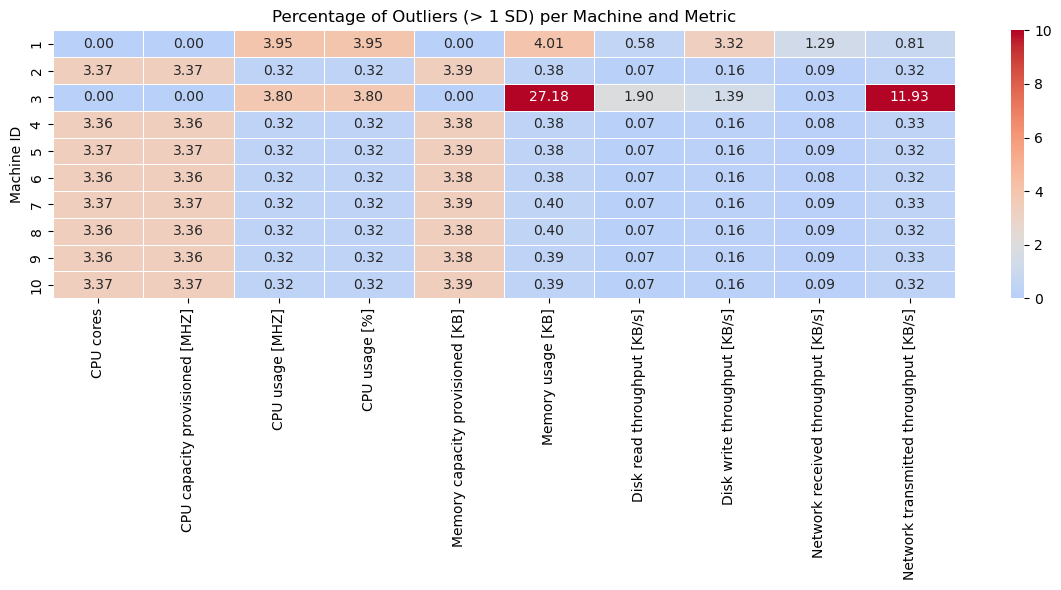

In [33]:
outlier_pct_per_machine

plt.figure(figsize=(12, 6))
sns.heatmap(
    outlier_pct_per_machine, 
    cmap="coolwarm", 
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=0,
    center=2,
    vmax=10
)

plt.title("Percentage of Outliers (> 1 SD) per Machine and Metric")
plt.ylabel("Machine ID")
plt.tight_layout()
plt.show()

If wanting visual, can graph scatterplot and boundary lines on the same axes or otherwise just return the dataframes or the range between the first and last, provided that it's sorted by timestamp

In [40]:
# 7. Outlier intervals per machine and metric (using 2SD)

N = 1250

interval_rows = []
for x in range(1, N + 1):
    df_x = (pd.read_csv(f"2013-8/{x}.csv", sep=";")
              .rename(columns=str.strip)
              .sort_values("Timestamp [ms]")
              .reset_index(drop=True))
    metrics_x = [c for c in df_x.columns if c != "Timestamp [ms]"]

    means = df_x[metrics_x].mean()
    stds = df_x[metrics_x].std()
    outside_x = (df_x[metrics_x] < means - 2*stds) | (df_x[metrics_x] > means + 2*stds)

    for metric in metrics_x:
        flag = outside_x[metric]
        run_id = (flag != flag.shift()).cumsum()
        for _, run in flag[flag].groupby(run_id[flag]):
            interval_rows.append({
                "machine_id": x,
                "metric": metric,
                "time_start_ms": df_x.loc[run.index.min(), "Timestamp [ms]"],
                "time_end_ms": df_x.loc[run.index.max(), "Timestamp [ms]"],
            })

outlier_intervals = pd.DataFrame(interval_rows)
outlier_intervals.to_csv(f"outlier_intervals_{N}_2sd.csv", index=False)
print(outlier_intervals.shape)
outlier_intervals.head()


(757827, 4)


,machine_id,metric,time_start_ms,time_end_ms
0,1,CPU usage [MHZ],1376314846,1376318146
1,1,CPU usage [MHZ],1376393453,1376393453
2,1,CPU usage [MHZ],1376397352,1376404253
3,1,CPU usage [MHZ],1376408754,1376424356
4,1,CPU usage [MHZ],1376458859,1376468159


I'm not pushing the 1250 machines csv because that was almost 758k lines and took ~45s to create